# 84 — LSEG-33 structured anticipated-reaction sentiment score

**Objective.** Test whether a direct −1 to +1 sentiment index representing
the anticipated first tradable stock reaction creates economic value. The
prompt does not assess novelty and receives no earlier headlines.

This is a user-directed post-Notebook-83 retrospective sensitivity. It is not
independent confirmation, scorer validation, or a deployable strategy.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "final_experiments":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from final_experiments.lib.lseg_materiality_returns import (  # noqa: E402
    attach_forward_open_returns,
    benjamini_hochberg_qvalues,
    circular_block_mean_test,
    load_preconfirmation_lseg_prices,
    run_sparse_strategy,
    summarize_sparse_strategy,
)
from final_experiments.lib.lseg_prompt_value import (  # noqa: E402
    EXPECTED_CANDIDATE_EVENTS,
    prompt_value_paths,
)
from final_experiments.lib.lseg_structured_reaction import (  # noqa: E402
    HORIZON_SESSIONS,
    load_structured_reaction_prompt,
    structured_reaction_paths,
)
from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    annotate_source,
    apply_house_style,
    zero_line,
)
from sentiment_benchmark.artifact_io import (  # noqa: E402
    atomic_write_json,
    read_json,
    read_jsonl,
    sha256_file,
)

apply_house_style()
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

SPEC_PATH = ROOT / (
    "final_experiments/frozen_specs/"
    "lseg_structured_reaction_score_v1_20260813.json"
)
OPERATIONAL_PATH = ROOT / (
    "final_experiments/frozen_specs/"
    "lseg_structured_reaction_score_operational_concurrency_amendment_20260813.json"
)
CHRONOLOGICAL_PATH = ROOT / (
    "final_experiments/frozen_specs/"
    "lseg_structured_reaction_score_chronological_scoring_amendment_20260813.json"
)
POSTFLIGHT_PATH = ROOT / (
    "final_experiments/frozen_specs/"
    "lseg_structured_reaction_score_postflight_20260813.json"
)
PRICE_PATH = ROOT / "Data/derived/prices/lseg_us_sector_33_2024_2026.csv"
SOURCE_OUTPUT = ROOT / "final_experiments/outputs/83_lseg_prompt_economic_value"
OUTPUT = ROOT / "final_experiments/outputs/84_lseg_structured_reaction_score"
ANALYSIS_OUTPUT = OUTPUT / "analysis"
FIGURE_OUTPUT = ROOT / "dissertation/figures"
ANALYSIS_OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURE_OUTPUT.mkdir(parents=True, exist_ok=True)

SPEC = read_json(SPEC_PATH)
OPERATIONAL_AMENDMENT = read_json(OPERATIONAL_PATH)
CHRONOLOGICAL_AMENDMENT = read_json(CHRONOLOGICAL_PATH)
POSTFLIGHT = read_json(POSTFLIGHT_PATH)
assert SPEC["status"] == "frozen_before_paid_calls_and_new_reaction_scores"
assert OPERATIONAL_AMENDMENT["prices_or_returns_opened"] is False
assert CHRONOLOGICAL_AMENDMENT["prices_or_returns_opened"] is False
assert POSTFLIGHT["economic_gate"]["passed"] is False
assert SPEC["authorisation_and_privacy"]["earlier_headlines_sent"] is False
assert SPEC["authorisation_and_privacy"]["newness_assessed"] is False

SEED = 20_260_813
COST_BPS = 10.0
BLOCK_LENGTH = 10
BOOTSTRAP_REPLICATIONS = 9_999
SELECTION_START = pd.Timestamp("2024-01-01")
TEST_START = pd.Timestamp("2025-01-01")
CONFIRMATION_START = pd.Timestamp("2026-01-01")

PROMPT = load_structured_reaction_prompt(
    ROOT / "configs/strategy_research/lseg_structured_reaction_score_v1.toml"
)
assert PROMPT.prompt_hash == SPEC["model_and_prompt"]["prompt_hash"]
assert HORIZON_SESSIONS == 1

print("prompt:", PROMPT.prompt_id, PROMPT.prompt_hash)
print("earlier headlines sent:", False)
print("newness assessed:", False)
print("score meaning: anticipated first tradable reaction, not return percentage")
print("2026 confirmation sealed:", True)

prompt: structured_first_reaction_v1 bc92cd43827a2be1
earlier headlines sent: False
newness assessed: False
score meaning: anticipated first tradable reaction, not return percentage
2026 confirmation sealed: True


## Return-blind score and quality gate

The fixed score grid is −1, −0.75, …, +1. Only strict outputs are retained.
At least 98% of the fixed 9,317-event parent, all 33 companies and both 2024
and 2025 must survive before any price is opened.

In [2]:
source_paths = prompt_value_paths(SOURCE_OUTPUT)
reaction_paths = structured_reaction_paths(OUTPUT)
candidate_manifest = read_json(source_paths.candidate_manifest)
score_manifest = read_json(reaction_paths.manifest)

assert candidate_manifest["counts"]["candidate_events"] == EXPECTED_CANDIDATE_EVENTS
assert candidate_manifest["selection"]["prices_or_returns_loaded"] is False
scope_events = int(score_manifest["counts"]["scoring_scope_events"])
assert score_manifest["counts"]["successful_unique"] >= (
    SPEC["population"]["minimum_strict_success_share"] * scope_events
)
assert score_manifest["identity"]["prompt_hash"] == PROMPT.prompt_hash
assert score_manifest["identity"]["prior_headlines_rendered"] is False
assert score_manifest["identity"]["newness_assessed"] is False

candidates = pd.DataFrame(read_jsonl(source_paths.candidate_events))
candidates["entry_session"] = pd.to_datetime(
    candidates["entry_session"], errors="raise"
).dt.normalize()
scope_end_raw = score_manifest["scoring_scope"]["end_entry_session_exclusive"]
scope_end = pd.Timestamp(scope_end_raw) if scope_end_raw else CONFIRMATION_START
scoped_candidates = candidates.loc[candidates["entry_session"].lt(scope_end)].copy()
assert len(scoped_candidates) == scope_events
scores = pd.DataFrame(read_jsonl(reaction_paths.scores))
assert len(candidates) == EXPECTED_CANDIDATE_EVENTS
assert scores["status"].eq("success").all()
assert scores["prior_headlines_rendered"].eq(False).all()  # noqa: E712
assert scores["newness_assessed"].eq(False).all()  # noqa: E712
assert scores["prompt_event_id"].is_unique

score_columns = [
    "prompt_event_id",
    "headline_sha256",
    "target_specific",
    "expectation_revision",
    "persistence",
    "first_tradable_reaction",
    "reaction_score",
    "trade_signal",
]
panel = scoped_candidates.merge(
    scores[score_columns],
    on=["prompt_event_id", "headline_sha256"],
    how="inner",
    validate="one_to_one",
)
panel["audit_id"] = panel["prompt_event_id"]

retained_share = len(panel) / scope_events
assert retained_share >= SPEC["population"]["minimum_strict_success_share"]
assert panel["symbol"].nunique() == 33
assert 2024 in set(panel["entry_session"].dt.year.unique())

support = pd.DataFrame(
    [
        {
            "parent_events": EXPECTED_CANDIDATE_EVENTS,
            "scoring_scope_events": scope_events,
            "scoring_scope_end_exclusive": scope_end.date().isoformat(),
            "strict_scores": len(scores),
            "strict_retained_share": retained_share,
            "missing_strict_scores_within_scope": scope_events - len(scores),
            "unscored_parent_events_after_scope": (
                EXPECTED_CANDIDATE_EVENTS - scope_events
            ),
            "companies": panel["symbol"].nunique(),
            "sessions": panel["entry_session"].nunique(),
            "target_specific_share": scores["target_specific"].mean(),
            "nonzero_score_share": scores["reaction_score"].ne(0).mean(),
            "newness_assessed": False,
            "earlier_headlines_sent": False,
            "reported_api_cost_usd": score_manifest["usage"][
                "reported_new_experiment_cost_usd"
            ],
            "reported_combined_prompt_cost_usd": score_manifest["usage"][
                "reported_combined_cost_usd"
            ],
        }
    ]
)
score_distribution = (
    scores.groupby(
        [
            "reaction_score",
            "first_tradable_reaction",
            "expectation_revision",
            "persistence",
        ],
        dropna=False,
    )
    .size()
    .rename("events")
    .reset_index()
)
display(support.T)
display(
    scores.groupby("reaction_score").size().rename("events").to_frame().T
)

,0
parent_events,9317
scoring_scope_events,3242
scoring_scope_end_exclusive,2025-01-01
strict_scores,3241
strict_retained_share,0.999692
missing_strict_scores_within_scope,1
unscored_parent_events_after_scope,6075
companies,33
sessions,252
target_specific_share,0.930886


reaction_score,-0.750000,-0.500000,-0.250000,0.000000,0.250000,0.500000,0.750000
events,77,435,226,1551,485,370,97


## 2024 economic selection only

No 2025 event return is attached unless the fixed 2024 gate passes. Existing
Gemma and FinBERT comparators trade on exactly the reaction score's formation
dates and use deterministic within-day score ranks to match exposure.

In [3]:
prices, price_audit = load_preconfirmation_lseg_prices(
    PRICE_PATH,
    expected_sha256=SPEC["immutable_inputs"]["price_export"]["sha256"],
)
selection_events = panel.loc[
    panel["entry_session"].ge(SELECTION_START)
    & panel["entry_session"].lt(TEST_START)
].copy()
selection_return_panel, wide_prices = attach_forward_open_returns(
    selection_events,
    prices,
    horizons=(1,),
)
assert price_audit["numeric_confirmation_prices_parsed"] == 0
assert selection_return_panel["entry_session"].max() < TEST_START


def run_window(
    events: pd.DataFrame,
    *,
    signal_col: str,
    start: pd.Timestamp,
    end: pd.Timestamp,
    formation_dates: set[pd.Timestamp] | None = None,
    force_cross_sectional_extremes: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, object]]:
    """Run one h1 window without allowing outcomes to cross its end."""

    use = events.loc[
        events["entry_session"].ge(start)
        & events["entry_session"].lt(end)
        & events["ret_open_h1"].notna()
        & events["return_end_h1"].lt(end)
    ].copy()
    if formation_dates is not None:
        use = use.loc[use["entry_session"].isin(formation_dates)].copy()
    effective_signal = signal_col
    if force_cross_sectional_extremes:
        effective_signal = f"{signal_col}__cross_sectional_order"
        use = use.sort_values(
            ["entry_session", signal_col, "prompt_event_id"], kind="mergesort"
        )
        order = use.groupby("entry_session", sort=False).cumcount().astype(float)
        size = use.groupby("entry_session", sort=False)["prompt_event_id"].transform(
            "size"
        )
        use[effective_signal] = order - (size.astype(float) - 1.0) / 2.0
    daily, formations = run_sparse_strategy(
        use,
        wide_prices,
        signal_col=effective_signal,
        horizon=1,
        cost_bps_per_side=COST_BPS,
    )
    daily = daily.loc[
        daily["session_date"].ge(start) & daily["return_end_date"].lt(end)
    ].reset_index(drop=True)
    return daily, formations, {
        "formation_sessions": len(formations),
        **summarize_sparse_strategy(daily, cost_bps_per_side=COST_BPS),
    }


def reaction_and_matched_baselines(
    events: pd.DataFrame,
    *,
    start: pd.Timestamp,
    end: pd.Timestamp,
) -> dict[str, object]:
    reaction_daily, reaction_formations, reaction_summary = run_window(
        events,
        signal_col="trade_signal",
        start=start,
        end=end,
    )
    dates = set(pd.to_datetime(reaction_formations["entry_session"]).dt.normalize())
    result: dict[str, object] = {
        "reaction_daily": reaction_daily,
        "reaction_formations": reaction_formations,
        "reaction_summary": reaction_summary,
    }
    for baseline in ("score_gemma", "score_finbert"):
        daily, formations, summary = run_window(
            events,
            signal_col=baseline,
            start=start,
            end=end,
            formation_dates=dates,
            force_cross_sectional_extremes=True,
        )
        observed_dates = set(
            pd.to_datetime(formations["entry_session"]).dt.normalize()
        )
        if observed_dates != dates:
            raise AssertionError(f"{baseline} did not match reaction formation dates")
        result[f"{baseline}_daily"] = daily
        result[f"{baseline}_formations"] = formations
        result[f"{baseline}_summary"] = summary
    return result


quarter_bounds = tuple(
    (pd.Timestamp(start), pd.Timestamp(end))
    for start, end in (
        ("2024-01-01", "2024-04-01"),
        ("2024-04-01", "2024-07-01"),
        ("2024-07-01", "2024-10-01"),
        ("2024-10-01", "2025-01-01"),
    )
)

development = reaction_and_matched_baselines(
    selection_return_panel,
    start=SELECTION_START,
    end=TEST_START,
)
quarter_rows: list[dict[str, object]] = []
for quarter, (start, end) in enumerate(quarter_bounds, start=1):
    result = reaction_and_matched_baselines(
        selection_return_panel,
        start=start,
        end=end,
    )
    row = {
        "quarter": quarter,
        "start": start.date().isoformat(),
        "end_exclusive": end.date().isoformat(),
        "formation_sessions": result["reaction_summary"]["formation_sessions"],
        "reaction_net_bps_session": result["reaction_summary"][
            "mean_net_bps_session"
        ],
        "gemma_net_bps_session": result["score_gemma_summary"][
            "mean_net_bps_session"
        ],
        "finbert_net_bps_session": result["score_finbert_summary"][
            "mean_net_bps_session"
        ],
    }
    row["reaction_minus_gemma_bps"] = (
        row["reaction_net_bps_session"] - row["gemma_net_bps_session"]
    )
    row["reaction_minus_finbert_bps"] = (
        row["reaction_net_bps_session"] - row["finbert_net_bps_session"]
    )
    quarter_rows.append(row)
quarters = pd.DataFrame(quarter_rows)

summary = development["reaction_summary"]
positive_quarters = int(quarters["reaction_net_bps_session"].gt(0).sum())
beat_gemma_quarters = int(quarters["reaction_minus_gemma_bps"].gt(0).sum())
beat_finbert_quarters = int(quarters["reaction_minus_finbert_bps"].gt(0).sum())
selection_pass = bool(
    int(summary["formation_sessions"]) >= 80
    and float(summary["mean_gross_bps_session"]) > 0
    and float(summary["mean_net_bps_session"]) > 0
    and float(summary["net_sharpe"]) > 0
    and float(summary["breakeven_bps_per_side"]) >= COST_BPS
    and positive_quarters >= 3
    and beat_gemma_quarters >= 3
    and beat_finbert_quarters >= 3
)

selection = pd.DataFrame(
    [
        {
            "prompt_id": PROMPT.prompt_id,
            **summary,
            "same_date_gemma_mean_net_bps_session": development[
                "score_gemma_summary"
            ]["mean_net_bps_session"],
            "same_date_gemma_total_return_net": development["score_gemma_summary"][
                "total_return_net"
            ],
            "same_date_finbert_mean_net_bps_session": development[
                "score_finbert_summary"
            ]["mean_net_bps_session"],
            "same_date_finbert_total_return_net": development[
                "score_finbert_summary"
            ]["total_return_net"],
            "positive_quarters": positive_quarters,
            "beat_same_date_gemma_quarters": beat_gemma_quarters,
            "beat_same_date_finbert_quarters": beat_finbert_quarters,
            "selection_pass": selection_pass,
        }
    ]
)
display(selection.T)
display(quarters)
print("2024 gate passed:", selection_pass)
print("2025 prompt portfolio computed:", False if not selection_pass else "conditional")

,0
prompt_id,structured_first_reaction_v1
formation_sessions,234
n_sessions,251
active_holding_sessions,234
mean_gross_bps_session,-2.589618
mean_net_bps_session,-19.665831
gross_sharpe,-0.286754
net_sharpe,-2.178291
total_return_gross,-0.086599
total_return_net,-0.405329


,quarter,start,end_exclusive,formation_sessions,reaction_net_bps_session,gemma_net_bps_session,finbert_net_bps_session,reaction_minus_gemma_bps,reaction_minus_finbert_bps
0,1,2024-01-01,2024-04-01,57,-31.092341,-21.688857,-10.366856,-9.403484,-20.725485
1,2,2024-04-01,2024-07-01,60,-28.833862,-16.367275,-13.805512,-12.466587,-15.028349
2,3,2024-07-01,2024-10-01,58,-25.499335,-13.061187,-6.229095,-12.438147,-19.270239
3,4,2024-10-01,2025-01-01,56,5.898245,-24.735434,-10.633687,30.633679,16.531932


2024 gate passed: False
2025 prompt portfolio computed: False


findfont: Failed to find font weight medium, now using 400.


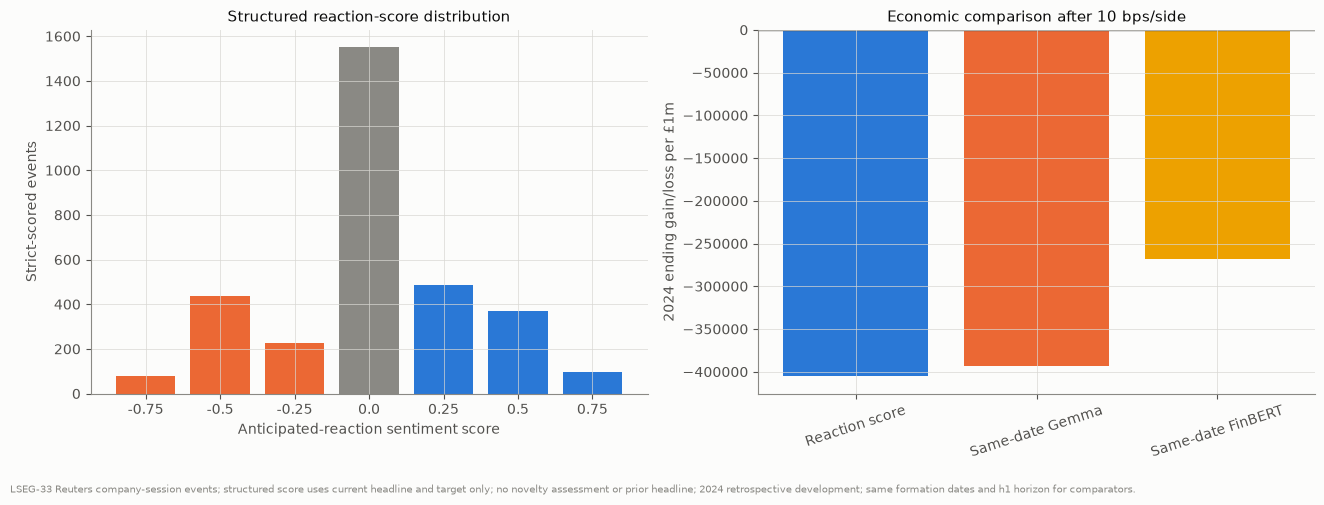

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))
score_counts = scores["reaction_score"].value_counts().sort_index()
axes[0].bar(
    score_counts.index.astype(str),
    score_counts.values,
    color=[
        CATEGORICAL[1] if score < 0 else CATEGORICAL[0] if score > 0 else INK["muted"]
        for score in score_counts.index
    ],
)
axes[0].set_xlabel("Anticipated-reaction sentiment score")
axes[0].set_ylabel("Strict-scored events")
axes[0].set_title("Structured reaction-score distribution")

labels = ["Reaction score", "Same-date Gemma", "Same-date FinBERT"]
values = np.asarray(
    [
        summary["total_return_net"],
        development["score_gemma_summary"]["total_return_net"],
        development["score_finbert_summary"]["total_return_net"],
    ]
) * 1_000_000.0
axes[1].bar(labels, values, color=[CATEGORICAL[0], CATEGORICAL[1], CATEGORICAL[3]])
zero_line(axes[1])
axes[1].set_ylabel("2024 ending gain/loss per £1m")
axes[1].set_title("Economic comparison after 10 bps/side")
axes[1].tick_params(axis="x", rotation=18)
fig.tight_layout()
annotate_source(
    fig,
    "LSEG-33 Reuters company-session events; structured score uses current headline and "
    "target only; no novelty assessment or prior headline; 2024 retrospective development; "
    "same formation dates and h1 horizon for comparators.",
)
fig.savefig(ANALYSIS_OUTPUT / "structured_reaction_2024.png", dpi=180, bbox_inches="tight")
fig.savefig(
    FIGURE_OUTPUT / "fig_lseg33_structured_reaction_score.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## Conditional 2025 retrospective test

This block attaches 2025 event returns only if every fixed 2024 condition
passes. The underlying dates have been explored elsewhere, so this cannot be
described as pristine confirmation even if it runs.

In [5]:
evaluation_summary = pd.DataFrame()
primary_family = pd.DataFrame()
half_stability = pd.DataFrame()
evaluation: dict[str, object] | None = None
evaluation_event_returns_materialised = 0
economic_gate_pass = False

if selection_pass:
    if scope_end < CONFIRMATION_START:
        raise RuntimeError(
            "2024 selection passed; score the fixed 2025 scope before rerunning "
            "the conditional evaluation"
        )
    evaluation_events = panel.loc[
        panel["entry_session"].ge(TEST_START)
        & panel["entry_session"].lt(CONFIRMATION_START)
    ].copy()
    evaluation_return_panel, _ = attach_forward_open_returns(
        evaluation_events,
        prices,
        horizons=(1,),
    )
    evaluation_event_returns_materialised = len(evaluation_return_panel)
    evaluation = reaction_and_matched_baselines(
        evaluation_return_panel,
        start=TEST_START,
        end=CONFIRMATION_START,
    )
    evaluation_summary = pd.DataFrame(
        [
            {"arm": "reaction", **evaluation["reaction_summary"]},
            {"arm": "score_gemma", **evaluation["score_gemma_summary"]},
            {"arm": "score_finbert", **evaluation["score_finbert_summary"]},
        ]
    )

    def paired_difference(left: pd.DataFrame, right: pd.DataFrame) -> pd.Series:
        joined = left[["session_date", "net_return"]].merge(
            right[["session_date", "net_return"]],
            on="session_date",
            how="inner",
            validate="one_to_one",
            suffixes=("_left", "_right"),
        )
        return joined["net_return_left"] - joined["net_return_right"]

    tests: list[dict[str, object]] = []
    cash_test = circular_block_mean_test(
        evaluation["reaction_daily"]["net_return"],
        block_length=BLOCK_LENGTH,
        replications=BOOTSTRAP_REPLICATIONS,
        seed=SEED + 1,
        alternative="greater",
    )
    tests.append(
        {
            "test": "reaction_vs_cash",
            "effect_bps_session": cash_test["mean"] * 10_000.0,
            "ci_low_bps": cash_test["ci_low"] * 10_000.0,
            "ci_high_bps": cash_test["ci_high"] * 10_000.0,
            "p_one_sided": cash_test["p"],
        }
    )
    for offset, baseline in enumerate(("score_gemma", "score_finbert"), start=2):
        difference = paired_difference(
            evaluation["reaction_daily"],
            evaluation[f"{baseline}_daily"],
        )
        test = circular_block_mean_test(
            difference,
            block_length=BLOCK_LENGTH,
            replications=BOOTSTRAP_REPLICATIONS,
            seed=SEED + offset,
            alternative="greater",
        )
        tests.append(
            {
                "test": f"reaction_vs_same_date_{baseline}",
                "effect_bps_session": test["mean"] * 10_000.0,
                "ci_low_bps": test["ci_low"] * 10_000.0,
                "ci_high_bps": test["ci_high"] * 10_000.0,
                "p_one_sided": test["p"],
            }
        )
    primary_family = pd.DataFrame(tests)
    primary_family["bh_q"] = benjamini_hochberg_qvalues(
        primary_family["p_one_sided"]
    )
    primary_family["reject_q05"] = (
        primary_family["effect_bps_session"].gt(0)
        & primary_family["bh_q"].lt(0.05)
    )

    halves: list[dict[str, object]] = []
    for half, start, end in (
        (1, TEST_START, pd.Timestamp("2025-07-01")),
        (2, pd.Timestamp("2025-07-01"), CONFIRMATION_START),
    ):
        result = reaction_and_matched_baselines(
            evaluation_return_panel,
            start=start,
            end=end,
        )
        halves.append({"half": half, **result["reaction_summary"]})
    half_stability = pd.DataFrame(halves)
    reaction_2025 = evaluation_summary.set_index("arm").loc["reaction"]
    economic_gate_pass = bool(
        primary_family["reject_q05"].all()
        and float(reaction_2025["net_sharpe"]) > 0
        and float(reaction_2025["breakeven_bps_per_side"]) >= COST_BPS
        and float(reaction_2025["total_return_net"]) > 0
        and half_stability["mean_net_bps_session"].gt(0).all()
    )
    display(evaluation_summary)
    display(primary_family)
    display(half_stability)
    print("complete 2025 economic gate:", economic_gate_pass)
else:
    display(
        Markdown(
            "**Frozen stop:** the structured reaction score failed the 2024 gate, "
            "so no 2025 reaction-score event return or portfolio was computed."
        )
    )

**Frozen stop:** the structured reaction score failed the 2024 gate, so no 2025 reaction-score event return or portfolio was computed.

## Persist aggregate evidence

Reuters text and row-level scores remain ignored. Only aggregate tables,
figures and a hash-bound manifest are promoted.

In [6]:
tables = {
    "support.csv": support,
    "score_distribution.csv": score_distribution,
    "selection_2024.csv": selection,
    "selection_quarters_2024.csv": quarters,
    "evaluation_summary_2025.csv": evaluation_summary,
    "primary_family_2025.csv": primary_family,
    "half_stability_2025.csv": half_stability,
}
for filename, table in tables.items():
    table.to_csv(ANALYSIS_OUTPUT / filename, index=False)

if not selection_pass:
    decision = (
        "The no-newness structured anticipated-reaction sentiment score fails the "
        "fixed 2024 economic and stability gate. No 2025 reaction-score portfolio "
        "is computed. Preserve this post-result prompt sensitivity as a null."
    )
elif economic_gate_pass:
    decision = (
        "The structured anticipated-reaction score passes the retrospective 2025 "
        "gate, but remains post-result iterative evidence requiring new-date confirmation."
    )
else:
    decision = (
        "The structured anticipated-reaction score passed 2024 selection but failed "
        "the complete retrospective 2025 gate. Preserve the failure without retuning."
    )

aggregate_outputs = sorted(
    list(ANALYSIS_OUTPUT.glob("*.csv")) + list(ANALYSIS_OUTPUT.glob("*.png"))
)
promoted_outputs = sorted(
    path
    for path in (FIGURE_OUTPUT / "fig_lseg33_structured_reaction_score.png",)
    if path.is_file()
)
manifest = {
    "schema_version": 1,
    "status": "complete",
    "notebook": "84_lseg_structured_reaction_score.ipynb",
    "git_commit_at_execution": subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=ROOT, text=True
    ).strip(),
    "evidence_role": "user-directed post-Notebook-83 retrospective sensitivity",
    "frozen_spec": {
        "path": str(SPEC_PATH.relative_to(ROOT)),
        "sha256": sha256_file(SPEC_PATH),
    },
    "operational_amendment": {
        "path": str(OPERATIONAL_PATH.relative_to(ROOT)),
        "sha256": sha256_file(OPERATIONAL_PATH),
    },
    "chronological_scoring_amendment": {
        "path": str(CHRONOLOGICAL_PATH.relative_to(ROOT)),
        "sha256": sha256_file(CHRONOLOGICAL_PATH),
    },
    "postflight_audit": {
        "path": str(POSTFLIGHT_PATH.relative_to(ROOT)),
        "sha256": sha256_file(POSTFLIGHT_PATH),
    },
    "inputs": {
        "candidate_events_sha256": sha256_file(source_paths.candidate_events),
        "candidate_manifest_sha256": sha256_file(source_paths.candidate_manifest),
        "score_manifest_sha256": sha256_file(reaction_paths.manifest),
        "scores_sha256": sha256_file(reaction_paths.scores),
        "price_export_sha256": sha256_file(PRICE_PATH),
    },
    "privacy": {
        "earlier_headlines_sent": False,
        "newness_assessed": False,
        "payload": "current Reuters headline plus target-company name and symbol only",
    },
    "support": json.loads(support.to_json(orient="records"))[0],
    "seal_audit": {
        **price_audit,
        "numeric_2026_prices_parsed": 0,
        "confirmation_returns_materialised": 0,
        "evaluation_2025_event_returns_materialised": (
            evaluation_event_returns_materialised
        ),
    },
    "selection": {
        "passed": selection_pass,
        "result": json.loads(selection.to_json(orient="records"))[0],
        "quarters": json.loads(quarters.to_json(orient="records")),
    },
    "evaluation": {
        "computed": selection_pass,
        "complete_economic_gate_pass": economic_gate_pass,
        "summary": json.loads(evaluation_summary.to_json(orient="records")),
        "primary_family": json.loads(primary_family.to_json(orient="records")),
        "half_stability": json.loads(half_stability.to_json(orient="records")),
    },
    "decision": decision,
    "claim_boundary": (
        "Designed after Notebook 83 outcomes and run on historically explored LSEG dates; "
        "not independent confirmation, validated alpha or deployment evidence."
    ),
    "outputs": {
        str(path.relative_to(ROOT)): sha256_file(path) for path in aggregate_outputs
    },
    "promoted_outputs": {
        str(path.relative_to(ROOT)): sha256_file(path) for path in promoted_outputs
    },
}
atomic_write_json(ANALYSIS_OUTPUT / "manifest.json", manifest)

display(Markdown(f"### Final verdict\n\n{decision}"))
print("2024 selection passed:", selection_pass)
print("2025 evaluation computed:", selection_pass)
print("complete economic-value gate:", economic_gate_pass)
print(
    "reported OpenRouter cost, USD:",
    f"{score_manifest['usage']['reported_new_experiment_cost_usd']:.6f}",
)
print("2026 prices/returns opened:", False)

### Final verdict

The no-newness structured anticipated-reaction sentiment score fails the fixed 2024 economic and stability gate. No 2025 reaction-score portfolio is computed. Preserve this post-result prompt sensitivity as a null.

2024 selection passed: False
2025 evaluation computed: False
complete economic-value gate: False
reported OpenRouter cost, USD: 0.189512
2026 prices/returns opened: False
